# Within-Episode POMDP Analysis

Analyze whether the model’s actions reflect **meaningful adaptation within an episode** (action depends on observation history), *not* across-episode learning.

Uses: trajectory.jsonl + metrics.json from a single run.

## 0) Setup and conventions

In [28]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc

# Paths: set RUN_DIR to your run directory, or set TRAJ_PATH / METRICS_PATH directly
RUN_DIR = Path("../results/huggingface_HuggingFaceTB_SmolLM-360M-Instruct_20260217_163450")
TRAJ_PATH = RUN_DIR / "trajectory.jsonl"
METRICS_PATH = RUN_DIR / "metrics.json"
OUTDIR = Path("outputs")
OUTDIR.mkdir(exist_ok=True)

VALID_ACTIONS = {"RUN", "TUMBLE"}
k = 5  # observation history length
m_values = [2, 3, 5]  # trend windows

warnings.filterwarnings("ignore", category=UserWarning)

## 1) Load + parse data

In [29]:
# 1.1 Read metrics
with open(METRICS_PATH) as f:
    metrics = json.load(f)
with open(OUTDIR / "metrics_pretty.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Metrics saved to", OUTDIR / "metrics_pretty.json")

Metrics saved to outputs/metrics_pretty.json


In [30]:
# 1.2 Read trajectory jsonl
rows = []
with open(TRAJ_PATH) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))
df = pd.DataFrame(rows)
print("Loaded", len(df), "rows")

Loaded 1432 rows


In [31]:
# 1.3 Normalize / flatten and derive action from raw_llm_output
def parse_action(raw):
    if raw is None or not isinstance(raw, str):
        return None, "empty_or_not_string"
    s = raw.strip().upper()
    if not s:
        return None, "empty"
    has_run = "RUN" in s
    has_tumble = "TUMBLE" in s
    if has_run and not has_tumble:
        return "RUN", None
    if has_tumble:
        return "TUMBLE", None
    if has_run and has_tumble:
        return None, "both"
    return None, "neither"

# Observation: our schema uses 'concentrations' not 'obs_history'
def get_obs_history(row):
    obs = row.get("observation") or {}
    if isinstance(obs, dict):
        return obs.get("concentrations") or obs.get("obs_history") or []
    return []

df["obs_history"] = df.apply(get_obs_history, axis=1)
df["episode_id"] = df["episode_id"].astype(int)
df["step"] = df["step"].astype(int)
df["reward"] = df.get("reward", 0.0)
df["done"] = df.get("done", False)

parsed = df["raw_llm_output"].apply(parse_action)
df["action_parsed"] = [p[0] for p in parsed]
df["action_invalid_reason"] = [p[1] for p in parsed]
df["action"] = df.get("action", df["action_parsed"])
df.loc[df["action_parsed"].notna(), "action"] = df.loc[df["action_parsed"].notna(), "action_parsed"]
df["action_valid"] = df["action"].isin(VALID_ACTIONS)
print("Action valid rate:", df["action_valid"].mean())
print(df["action_invalid_reason"].value_counts(dropna=False).head(10))

Action valid rate: 1.0
action_invalid_reason
neither    880
NaN        552
Name: count, dtype: int64


In [32]:
# 1.4 Sort and integrity checks
df = df.sort_values(["episode_id", "step"]).reset_index(drop=True)
dup = df.duplicated(subset=["episode_id", "step"], keep="last")
if dup.any():
    print("Warning: duplicate (episode_id, step); keeping last occurrence.")
    df = df[~dup].reset_index(drop=True)

basic = {
    "n_rows": len(df),
    "n_episodes": df["episode_id"].nunique(),
    "invalid_action_rate": 1 - df["action_valid"].mean(),
}
pd.DataFrame([basic]).to_csv(OUTDIR / "basic_counts.csv", index=False)
print("Rows:", basic["n_rows"], " Episodes:", basic["n_episodes"], " Invalid action rate:", f"{basic['invalid_action_rate']:.4f}")

Rows: 1432  Episodes: 100  Invalid action rate: 0.0000


## 2) Feature engineering (from obs_history only)

In [33]:
# 2.1 Validate and unpack obs_history (need >=2 readings so we get training data from step 1)
def ensure_history(h):
    h = list(h) if isinstance(h, (list, np.ndarray)) else []
    if len(h) >= 2:
        use = h[-5:] if len(h) >= 5 else h  # last 2..5 readings, no NaN padding
        return use, True
    return [np.nan] * 5, False

out = df["obs_history"].apply(ensure_history)
df["obs_list"] = [o[0] for o in out]
df["history_valid"] = [o[1] for o in out]
df["o_t"] = df["obs_list"].apply(lambda x: x[-1] if isinstance(x, list) and len(x) else np.nan)
df["o_t_1"] = df["obs_list"].apply(lambda x: x[-2] if isinstance(x, list) and len(x) >= 2 else np.nan)
for i in range(5):
    df[f"o_t_{i}"] = df["obs_list"].apply(lambda x, i=i: x[i] if isinstance(x, list) and len(x) > i else np.nan)
df["o_t_4"] = df["o_t"]
df["o_t_3"] = df["o_t_1"]

In [34]:
# 2.2 Trend / delta features (obs_list: 0=oldest, 4=newest; delta_k = o_t - mean of k previous)
def mean_prev_k(arr, k):
    a = np.asarray(arr)
    if not isinstance(a, np.ndarray) or len(a) < k + 1 or np.any(np.isnan(a)):
        return np.nan
    return np.mean(a[-(k+1):-1])  # k elements before last

df["delta_1"] = df["o_t"] - df["o_t_1"]
df["delta_2"] = df.apply(lambda r: r["o_t"] - mean_prev_k(r["obs_list"], 2) if r["history_valid"] else np.nan, axis=1)
df["delta_3"] = df.apply(lambda r: r["o_t"] - mean_prev_k(r["obs_list"], 3) if r["history_valid"] else np.nan, axis=1)
df["delta_4"] = df.apply(lambda r: r["o_t"] - mean_prev_k(r["obs_list"], 4) if r["history_valid"] else np.nan, axis=1)

def slope5(arr):
    try:
        a = np.asarray(arr, dtype=np.float64)
    except (ValueError, TypeError):
        return np.nan
    if not isinstance(a, np.ndarray) or a.size < 2 or np.any(np.isnan(a)):
        return np.nan
    x = np.arange(len(a))
    return float(np.polyfit(x, a, 1)[0])
df["slope_5"] = df["obs_list"].apply(slope5)
def safe_std(x):
    if not isinstance(x, (list, np.ndarray)) or len(x) == 0: return np.nan
    a = np.asarray(x, dtype=np.float64)
    return np.nanstd(a)
def safe_range(x):
    if not isinstance(x, (list, np.ndarray)) or len(x) == 0: return np.nan
    a = np.asarray(x, dtype=np.float64)
    return np.nanmax(a) - np.nanmin(a)
df["std_5"] = df["obs_list"].apply(safe_std)
df["var_5"] = df["std_5"] ** 2
df["range_5"] = df["obs_list"].apply(safe_range)

/Users/jchoudhari/Documents/projects_code/jchoudhari-sandbox/llm-bio/Gen_LLM_coordination/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/j1/p77pd2j57q19jwgmxqt6yrj40000gp/T/ipykernel_89144/3507747449.py:30: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(a) - np.nanmin(a)


In [35]:
# 2.3 Discretized regime labels
bins_delta3 = [-np.inf, -1, -0.2, 0.2, 1, np.inf]
labels_d3 = ["(-inf,-1]", "(-1,-0.2]", "(-0.2,0.2]", "(0.2,1]", "(1,inf)"]
df["delta_3_bin"] = pd.cut(df["delta_3"], bins=bins_delta3, labels=labels_d3)
q = df["std_5"].quantile([0.25, 0.5, 0.75])
df["noise_bin"] = pd.cut(df["std_5"], bins=[-np.inf, q[0.25], q[0.5], q[0.75], np.inf], labels=["Q1", "Q2", "Q3", "Q4"])

feat_cols = ["episode_id", "step", "action", "action_valid", "history_valid", "o_t", "o_t_1", "delta_1", "delta_2", "delta_3", "delta_4", "slope_5", "std_5", "var_5", "range_5", "delta_3_bin", "noise_bin", "reward", "done"]
step_features = df[[c for c in feat_cols if c in df.columns]].copy()
step_features.to_csv(OUTDIR / "step_features.csv", index=False)
print("Saved", OUTDIR / "step_features.csv")

Saved outputs/step_features.csv


## 3) Chemotaxis signature: P(RUN | trend)

In [36]:
df_valid = df[df["action_valid"] & df["history_valid"]].copy()
df_valid["action_run"] = (df_valid["action"] == "RUN").astype(int)

def wilson_ci(successes, n, z=1.96):
    p = successes / n if n else 0
    den = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / den
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return center - margin, center + margin

def p_run_by_feature(feature, n_bins=10):
    ser = df_valid[feature].dropna()
    if ser.empty:
        return pd.DataFrame()
    bins = pd.qcut(ser, q=min(n_bins, max(ser.nunique(), 2)), duplicates="drop")
    out = df_valid.assign(_bin=bins).groupby("_bin", observed=True).agg(
        p_run=("action_run", "mean"), n=("action_run", "count")
    ).reset_index()
    out["bin_center"] = out["_bin"].apply(lambda x: x.mid if hasattr(x, "mid") else str(x))
    ci = out.apply(lambda r: wilson_ci(r["p_run"] * r["n"], int(r["n"]), 1.96), axis=1)
    out["ci_lo"] = [c[0] for c in ci]
    out["ci_hi"] = [c[1] for c in ci]
    return out

p_run_delta3 = pd.DataFrame()
for feat in ["delta_1", "delta_3", "slope_5"]:
    if feat not in df_valid.columns:
        continue
    tbl = p_run_by_feature(feat)
    if not tbl.empty:
        tbl.to_csv(OUTDIR / f"p_run_by_{feat}.csv", index=False)
        if feat == "delta_3":
            p_run_delta3 = tbl.copy()

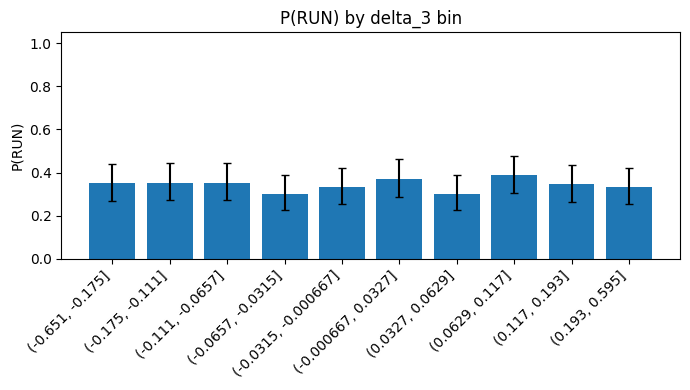

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
if not p_run_delta3.empty and "_bin" in p_run_delta3.columns:
    x = np.arange(len(p_run_delta3))
    err_lo = p_run_delta3["p_run"] - p_run_delta3["ci_lo"]
    err_hi = p_run_delta3["ci_hi"] - p_run_delta3["p_run"]
    ax.bar(x, p_run_delta3["p_run"], yerr=[err_lo, err_hi], capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([str(b)[:20] for b in p_run_delta3["_bin"]], rotation=45, ha="right")
ax.set_ylabel("P(RUN)")
ax.set_title("P(RUN) by delta_3 bin")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(OUTDIR / "p_run_by_delta3.png", dpi=120)
plt.show()

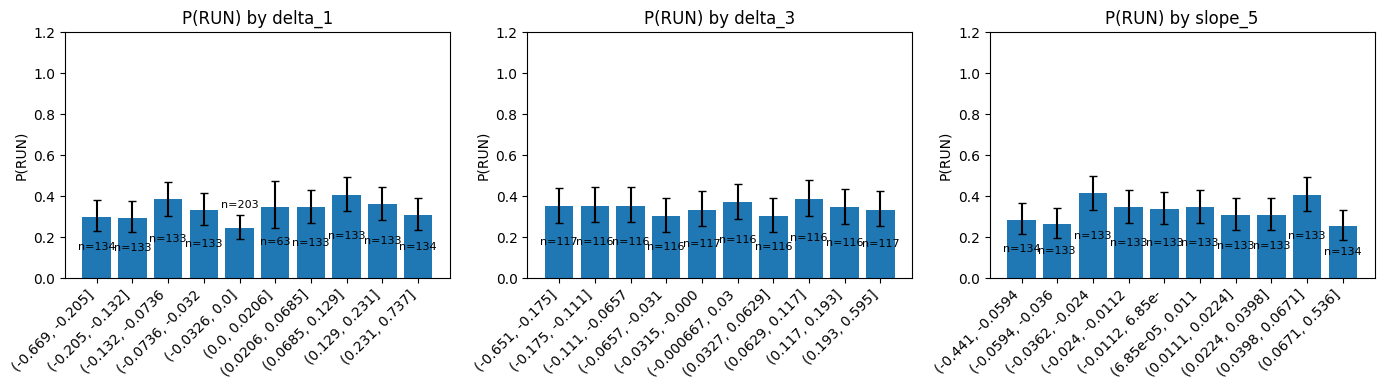

In [38]:
# Three plots: P(RUN) by delta_1, delta_3, slope_5 with count on each bar
p_run_d1 = p_run_by_feature("delta_1") if "delta_1" in df_valid.columns else pd.DataFrame()
p_run_s5 = p_run_by_feature("slope_5") if "slope_5" in df_valid.columns else pd.DataFrame()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (t, title) in zip(axes, [(p_run_d1, "P(RUN) by delta_1"), (p_run_delta3, "P(RUN) by delta_3"), (p_run_s5, "P(RUN) by slope_5")]):
    if t.empty or "_bin" not in t.columns:
        ax.set_title(title)
        continue
    x = np.arange(len(t))
    err_lo = t["p_run"] - t["ci_lo"]
    err_hi = t["ci_hi"] - t["p_run"]
    bars = ax.bar(x, t["p_run"], yerr=[err_lo, err_hi], capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([str(b)[:16] for b in t["_bin"]], rotation=45, ha="right")
    ax.set_ylabel("P(RUN)")
    ax.set_title(title)
    ax.set_ylim(0, 1.2)
    for i, (bar, n) in enumerate(zip(bars, t["n"])):
        h = bar.get_height()
        y_top = h + (err_hi.iloc[i] if i < len(err_hi) else 0)
        if h >= 0.25:
            ax.text(bar.get_x() + bar.get_width() / 2, h / 2, "n=%d" % int(n), ha="center", va="center", fontsize=8)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, y_top + 0.02, "n=%d" % int(n), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(OUTDIR / "p_run_by_delta1_delta3_slope5.png", dpi=120)
plt.show()

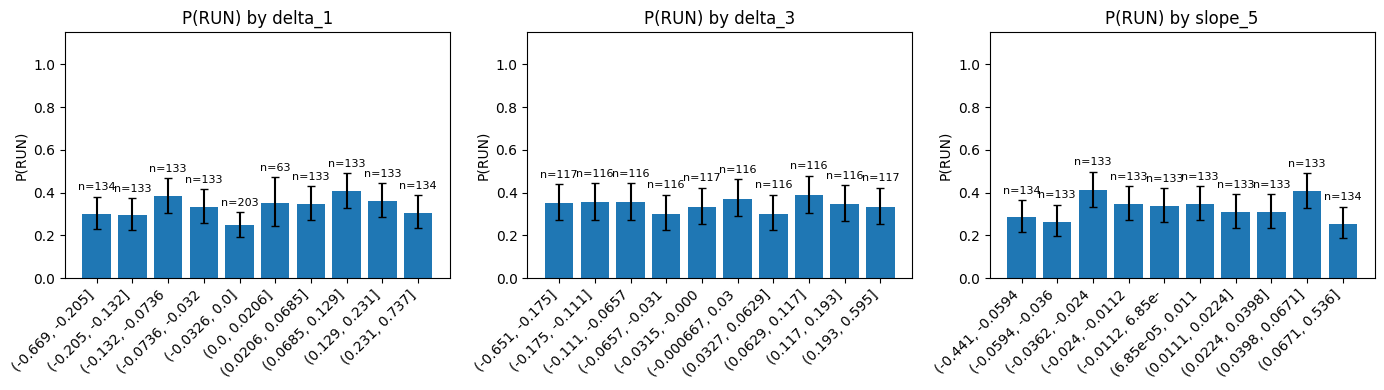

In [39]:
# Three plots: P(RUN) by delta_1, delta_3, slope_5 with count labels on each bar
p_run_delta1 = p_run_by_feature("delta_1") if "delta_1" in df_valid.columns else pd.DataFrame()
p_run_slope5 = p_run_by_feature("slope_5") if "slope_5" in df_valid.columns else pd.DataFrame()
tables = [
    (p_run_delta1, "delta_1", "P(RUN) by delta_1"),
    (p_run_delta3, "delta_3", "P(RUN) by delta_3"),
    (p_run_slope5, "slope_5", "P(RUN) by slope_5"),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, tbl, title in zip(axes, tables, [t[2] for t in tables]):
    t = tbl[0]
    if t.empty or "_bin" not in t.columns:
        ax.set_title(title)
        continue
    x = np.arange(len(t))
    err_lo = t["p_run"] - t["ci_lo"]
    err_hi = t["ci_hi"] - t["p_run"]
    bars = ax.bar(x, t["p_run"], yerr=[err_lo, err_hi], capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([str(b)[:16] for b in t["_bin"]], rotation=45, ha="right")
    ax.set_ylabel("P(RUN)")
    ax.set_title(title)
    ax.set_ylim(0, 1.15)
    # Add count labels on top of each bar
    for i, (bar, n) in enumerate(zip(bars, t["n"])):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + (err_hi.iloc[i] if i < len(err_hi) else 0) + 0.02, f"n={int(n)}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(OUTDIR / "p_run_by_delta1_delta3_slope5.png", dpi=120)
plt.show()

In [40]:
# A) Collapse bins into 2–3 regimes (delta_3 vs threshold tau)
# Use delta_3 only where valid
d3 = df_valid["delta_3"].dropna()
if len(d3) == 0:
    tau = 0.02  # fallback
else:
    med_abs = np.median(np.abs(d3))
    # Pick tau: median absolute delta, or 0.02/0.05 if that's more interpretable
    tau = float(med_abs) if med_abs > 1e-6 else 0.02
    if tau < 0.01:
        tau = 0.02
    elif tau > 0.1:
        tau = 0.05
print("tau =", round(tau, 4), "(threshold for |delta_3| regimes)")

# Regimes: up = delta_3 > tau, down = delta_3 < -tau, flat = |delta_3| <= tau
mask_up = df_valid["delta_3"] > tau
mask_down = df_valid["delta_3"] < -tau
mask_flat = (df_valid["delta_3"] >= -tau) & (df_valid["delta_3"] <= tau)

# P(RUN | regime) and counts
def p_run_and_n(mask):
    sub = df_valid.loc[mask]
    n = len(sub)
    p = sub["action_run"].mean() if n else np.nan
    return p, n

p_up, n_up = p_run_and_n(mask_up)
p_down, n_down = p_run_and_n(mask_down)
p_flat, n_flat = p_run_and_n(mask_flat)

regime_table = pd.DataFrame({
    "regime": ["delta_3 > +tau (up)", "delta_3 < -tau (down)", "|delta_3| <= tau (flat)"],
    "P(RUN)": [p_up, p_down, p_flat],
    "n": [n_up, n_down, n_flat],
})
print(regime_table.to_string(index=False))
regime_table.to_csv(OUTDIR / "p_run_by_regime.csv", index=False)

tau = 0.0882 (threshold for |delta_3| regimes)
                 regime   P(RUN)   n
    delta_3 > +tau (up) 0.339100 289
  delta_3 < -tau (down) 0.345890 292
|delta_3| <= tau (flat) 0.343643 582


In [41]:
# Bootstrap difference in proportions (e.g. P(RUN|up) - P(RUN|down))
np.random.seed(42)
n_boot = 2000
# Resample rows with replacement; compute P(RUN) per regime each time
diffs_up_down = []
diffs_up_flat = []
diffs_down_flat = []
for _ in range(n_boot):
    idx = np.random.choice(len(df_valid), size=len(df_valid), replace=True)
    b = df_valid.iloc[idx]
    m_u = b["delta_3"] > tau
    m_d = b["delta_3"] < -tau
    m_f = (b["delta_3"] >= -tau) & (b["delta_3"] <= tau)
    pu = b.loc[m_u, "action_run"].mean() if m_u.sum() else np.nan
    pd_ = b.loc[m_d, "action_run"].mean() if m_d.sum() else np.nan
    pf = b.loc[m_f, "action_run"].mean() if m_f.sum() else np.nan
    if not np.isnan(pu) and not np.isnan(pd_):
        diffs_up_down.append(pu - pd_)
    if not np.isnan(pu) and not np.isnan(pf):
        diffs_up_flat.append(pu - pf)
    if not np.isnan(pd_) and not np.isnan(pf):
        diffs_down_flat.append(pd_ - pf)

def ci_and_pval(diffs, name):
    diffs = np.array(diffs)
    if len(diffs) == 0:
        print(name, ": no bootstrap samples")
        return
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    pval_two = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    print(name, ": mean diff =", round(np.mean(diffs), 4), ", 95% CI =", round(ci_lo, 4), "to", round(ci_hi, 4), ", p (two-tailed) =", round(pval_two, 4))

ci_and_pval(diffs_up_down, "P(RUN|up) - P(RUN|down)")
ci_and_pval(diffs_up_flat, "P(RUN|up) - P(RUN|flat)")
ci_and_pval(diffs_down_flat, "P(RUN|down) - P(RUN|flat)")

# Save bootstrap summary
boot_summary = {
    "tau": float(tau),
    "n_boot": n_boot,
    "P_RUN_up": float(p_up), "n_up": int(n_up),
    "P_RUN_down": float(p_down), "n_down": int(n_down),
    "P_RUN_flat": float(p_flat), "n_flat": int(n_flat),
    "diff_up_down_mean": float(np.mean(diffs_up_down)) if diffs_up_down else None,
    "diff_up_down_ci95": [float(np.percentile(diffs_up_down, 2.5)), float(np.percentile(diffs_up_down, 97.5))] if diffs_up_down else None,
    "diff_up_flat_mean": float(np.mean(diffs_up_flat)) if diffs_up_flat else None,
    "diff_down_flat_mean": float(np.mean(diffs_down_flat)) if diffs_down_flat else None,
}
with open(OUTDIR / "regime_bootstrap_summary.json", "w") as f:
    json.dump(boot_summary, f, indent=2)
print("Saved", OUTDIR / "regime_bootstrap_summary.json")

P(RUN|up) - P(RUN|down) : mean diff = -0.0077 , 95% CI = -0.0876 to 0.0741 , p (two-tailed) = 0.828
P(RUN|up) - P(RUN|flat) : mean diff = -0.0044 , 95% CI = -0.0721 to 0.0628 , p (two-tailed) = 0.915
P(RUN|down) - P(RUN|flat) : mean diff = 0.0033 , 95% CI = -0.0668 to 0.0698 , p (two-tailed) = 0.913
Saved outputs/regime_bootstrap_summary.json


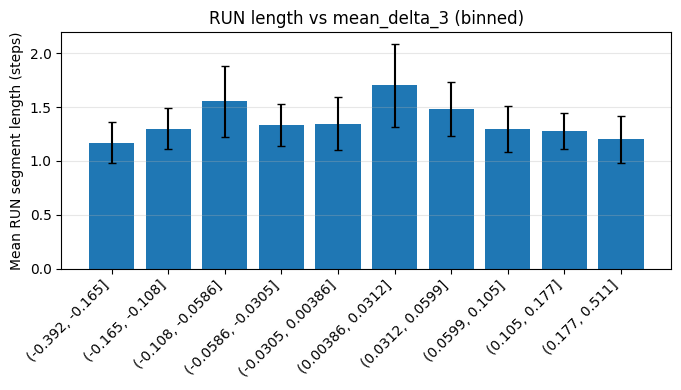

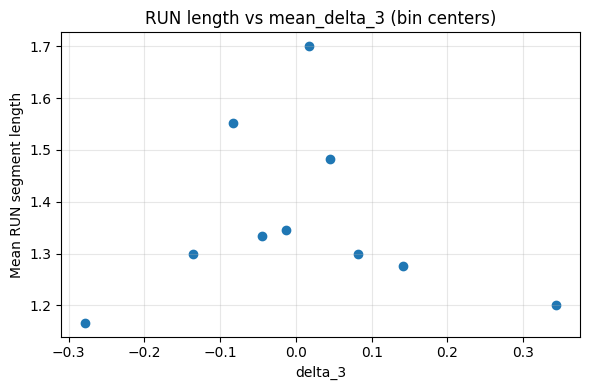

In [42]:
# --- Run-length vs delta (chemotaxis signature) ---
# Assumes df has: episode_id, step, action, action_valid, history_valid, delta_3 (or other delta feature)
# Uses matplotlib only.

df_valid = df[df["action_valid"] & df["history_valid"]].copy()
df_valid = df_valid.sort_values(["episode_id", "step"]).reset_index(drop=True)

# 1) Build action segments (consecutive RUN/TUMBLE blocks) per episode
segments = []
for ep, g in df_valid.groupby("episode_id", sort=False):
    g = g.sort_values("step")
    actions = g["action"].tolist()
    if not actions:
        continue

    start_idx = 0
    for i in range(1, len(actions) + 1):
        if i == len(actions) or actions[i] != actions[start_idx]:
            seg = g.iloc[start_idx:i]
            segments.append({
                "episode_id": ep,
                "start_step": int(seg["step"].iloc[0]),
                "end_step": int(seg["step"].iloc[-1]),
                "action": seg["action"].iloc[0],
                "segment_len": int(len(seg)),
                # feature summaries over the steps inside the segment:
                "mean_delta_3": float(seg["delta_3"].mean()) if "delta_3" in seg else np.nan,
                "mean_delta_1": float(seg["delta_1"].mean()) if "delta_1" in seg else np.nan,
                "mean_slope_5": float(seg["slope_5"].mean()) if "slope_5" in seg else np.nan,
                "mean_std_5": float(seg["std_5"].mean()) if "std_5" in seg else np.nan,
            })
            start_idx = i

segments_df = pd.DataFrame(segments)

# 2) Select RUN segments and choose which trend feature you want on x-axis
feature = "mean_delta_3"  # change to "mean_delta_1" or "mean_slope_5" if you want
run_segs = segments_df[(segments_df["action"] == "RUN") & segments_df[feature].notna()].copy()

# Optional: save segments
run_segs.to_csv(OUTDIR / "run_segments.csv", index=False)

# 3) Bin by the chosen trend feature and compute avg run length per bin
def run_length_vs_feature(run_segs: pd.DataFrame, feature: str, n_bins: int = 8) -> pd.DataFrame:
    ser = run_segs[feature].dropna()
    if ser.empty or ser.nunique() < 2:
        return pd.DataFrame()

    # Quantile bins give roughly equal counts per bin; duplicates='drop' handles repeated values.
    bins = pd.qcut(ser, q=min(n_bins, max(ser.nunique(), 2)), duplicates="drop")

    tbl = run_segs.assign(_bin=bins).groupby("_bin", observed=True).agg(
        mean_run_len=("segment_len", "mean"),
        median_run_len=("segment_len", "median"),
        n=("segment_len", "count"),
        std_run_len=("segment_len", "std"),
    ).reset_index()

    # Standard error + normal CI (fine here; you can bootstrap if you want)
    tbl["sem"] = tbl["std_run_len"] / np.sqrt(tbl["n"].clip(lower=1))
    z = 1.96
    tbl["ci_lo"] = tbl["mean_run_len"] - z * tbl["sem"]
    tbl["ci_hi"] = tbl["mean_run_len"] + z * tbl["sem"]
    tbl["bin_center"] = tbl["_bin"].apply(lambda x: x.mid if hasattr(x, "mid") else np.nan)

    return tbl

tbl = run_length_vs_feature(run_segs, feature=feature, n_bins=10)
tbl.to_csv(OUTDIR / f"run_length_vs_{feature}.csv", index=False)

# 4) Plot: mean RUN segment length vs feature bins, with CI
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
if not tbl.empty and "_bin" in tbl.columns:
    x = np.arange(len(tbl))
    err_lo = (tbl["mean_run_len"] - tbl["ci_lo"]).clip(lower=0)
    err_hi = (tbl["ci_hi"] - tbl["mean_run_len"]).clip(lower=0)

    ax.bar(x, tbl["mean_run_len"], yerr=[err_lo, err_hi], capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([str(b)[:20] for b in tbl["_bin"]], rotation=45, ha="right")
    ax.set_ylabel("Mean RUN segment length (steps)")
    ax.set_title(f"RUN length vs {feature} (binned)")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTDIR / f"run_length_vs_{feature}.png", dpi=120)
plt.show()

# 5) Optional: also plot as scatter (bin center vs mean length) for easier visual trend
if not tbl.empty and tbl["bin_center"].notna().any():
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.scatter(tbl["bin_center"], tbl["mean_run_len"])
    ax.set_xlabel(feature.replace("mean_", ""))
    ax.set_ylabel("Mean RUN segment length")
    ax.set_title(f"RUN length vs {feature} (bin centers)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTDIR / f"run_length_vs_{feature}_scatter.png", dpi=120)
    plt.show()

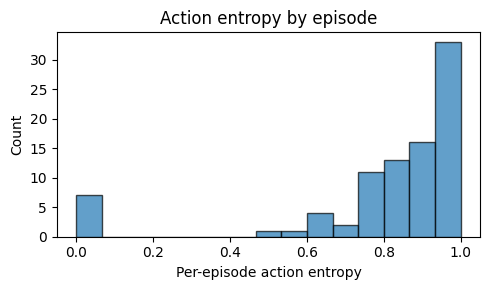

Overall alternation rate (RUN↔TUMBLE): 0.610092939220613


In [43]:
# 3B) Action entropy and alternation
def entropy(probs):
    p = np.array(probs)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

entropy_list = []
for eid, g in df_valid.groupby("episode_id"):
    acts = g["action"]
    n = len(acts)
    p_run = (acts == "RUN").mean()
    p_tumble = 1 - p_run
    ent = entropy([p_run, p_tumble]) if n else 0
    alt = (acts != acts.shift(1)).sum() / max(n - 1, 1)
    entropy_list.append({"episode_id": eid, "entropy": ent, "alternation_rate": alt, "n_steps": n})
ent_df = pd.DataFrame(entropy_list)
ent_df.to_csv(OUTDIR / "action_entropy_by_episode.csv", index=False)

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.hist(ent_df["entropy"], bins=15, edgecolor="black", alpha=0.7)
ax.set_xlabel("Per-episode action entropy")
ax.set_ylabel("Count")
ax.set_title("Action entropy by episode")
plt.tight_layout()
plt.savefig(OUTDIR / "action_entropy_hist.png", dpi=120)
plt.show()
print("Overall alternation rate (RUN↔TUMBLE):", df_valid.groupby("episode_id").apply(lambda g: (g["action"] != g["action"].shift(1)).sum() / max(len(g) - 1, 1)).mean())

## 4) Run-length and tumble hazard

In [44]:
# 4A) Action segments
segments = []
for eid, g in df_valid.sort_values(["episode_id", "step"]).groupby("episode_id"):
    g = g.reset_index(drop=True)
    act = g["action"]
    seg_start = 0
    for i in range(1, len(act) + 1):
        if i == len(act) or act.iloc[i] != act.iloc[seg_start]:
            seg_end = i - 1
            seg = g.iloc[seg_start:seg_end + 1]
            segments.append({
                "episode_id": eid,
                "segment_start_step": int(seg["step"].iloc[0]),
                "segment_end_step": int(seg["step"].iloc[-1]),
                "action": act.iloc[seg_start],
                "segment_len": len(seg),
                "mean_delta_3": seg["delta_3"].mean(),
                "mean_slope_5": seg["slope_5"].mean(),
                "mean_std_5": seg["std_5"].mean(),
            })
            seg_start = i
seg_df = pd.DataFrame(segments)
seg_df.to_csv(OUTDIR / "action_segments.csv", index=False)
print("Segments:", len(seg_df))

Segments: 685


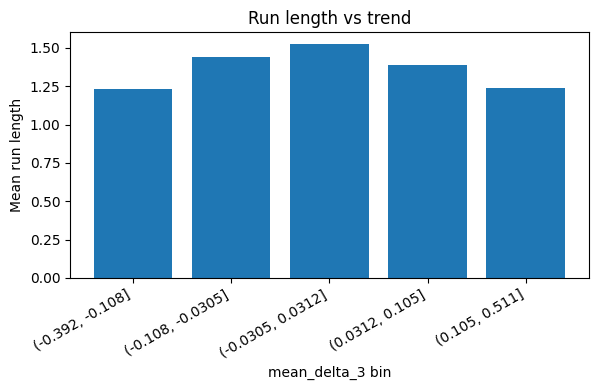

In [45]:
# 4B) Run length vs trend
rho, pval = None, None
runs = seg_df[seg_df["action"] == "RUN"].copy()
if not runs.empty and runs["mean_delta_3"].notna().any():
    runs["delta3_bin"] = pd.qcut(runs["mean_delta_3"].dropna(), q=5, duplicates="drop")
    rl = runs.groupby("delta3_bin", observed=True).agg(mean_run_len=("segment_len", "mean"), n=("segment_len", "count")).reset_index()
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    x = np.arange(len(rl))
    ax.bar(x, rl["mean_run_len"])
    ax.set_xticks(x)
    ax.set_xticklabels([str(b)[:25] for b in rl["delta3_bin"]], rotation=30, ha="right")
    ax.set_ylabel("Mean run length")
    ax.set_xlabel("mean_delta_3 bin")
    ax.set_title("Run length vs trend")
    plt.tight_layout()
    plt.savefig(OUTDIR / "run_length_vs_trend.png", dpi=120)
    plt.show()

    rho, pval = stats.spearmanr(runs["mean_delta_3"], runs["segment_len"])
    with open(OUTDIR / "runlen_trend_corr.json", "w") as f:
        json.dump({"spearman_rho": float(rho), "spearman_p": float(pval)}, f)
else:
    rho, pval = None, None
    with open(OUTDIR / "runlen_trend_corr.json", "w") as f:
        json.dump({"spearman_rho": None, "spearman_p": None}, f)

In [46]:
# 4C) Tumble hazard
df_valid["tumble_next"] = 0
df_valid = df_valid.sort_values(["episode_id", "step"]).reset_index(drop=True)
for i in range(len(df_valid) - 1):
    if df_valid.iloc[i]["action"] == "RUN" and df_valid.iloc[i]["episode_id"] == df_valid.iloc[i + 1]["episode_id"]:
        if df_valid.iloc[i + 1]["action"] == "TUMBLE":
            df_valid.iloc[i, df_valid.columns.get_loc("tumble_next")] = 1
hazard = df_valid[df_valid["action"] == "RUN"].groupby(["delta_3_bin", "noise_bin"], observed=True).agg(
    tumble_next_mean=("tumble_next", "mean"), n=("tumble_next", "count")
).reset_index()
hazard.to_csv(OUTDIR / "tumble_hazard_table.csv", index=False)

## 5) Excess tumbling decomposition

In [47]:
thr_pos, thr_neg = 0.2, -0.2
mid = (thr_neg, thr_pos)
df_valid["regime"] = "ambiguous"
df_valid.loc[df_valid["delta_3"] > thr_pos, "regime"] = "positive"
df_valid.loc[df_valid["delta_3"] < thr_neg, "regime"] = "negative"
df_valid["wasted_tumble_pos"] = ((df_valid["delta_3"] > thr_pos) & (df_valid["action"] == "TUMBLE")).astype(int)
df_valid["wasted_run_neg"] = ((df_valid["delta_3"] < thr_neg) & (df_valid["action"] == "RUN")).astype(int)

by_ep = df_valid.groupby("episode_id").agg(
    wasted_tumble_pos=("wasted_tumble_pos", "sum"),
    wasted_run_neg=("wasted_run_neg", "sum"),
    ambiguous=("regime", lambda x: (x == "ambiguous").sum()),
).reset_index()
by_ep.to_csv(OUTDIR / "regime_mistakes_by_episode.csv", index=False)

overall = {
    "wasted_tumble_pos": df_valid["wasted_tumble_pos"].sum(),
    "wasted_run_neg": df_valid["wasted_run_neg"].sum(),
    "ambiguous_steps": (df_valid["regime"] == "ambiguous").sum(),
}
pd.DataFrame([overall]).to_csv(OUTDIR / "regime_mistakes_overall.csv", index=False)

## 6) Policy extraction (LogReg + Tree)

In [48]:
df_valid.columns

Index(['step', 'observation', 'action', 'raw_llm_output', 'hidden_state',
       'info', 'reward', 'done', 'episode_id', 'obs_history', 'action_parsed',
       'action_invalid_reason', 'action_valid', 'obs_list', 'history_valid',
       'o_t', 'o_t_1', 'o_t_0', 'o_t_2', 'o_t_3', 'o_t_4', 'delta_1',
       'delta_2', 'delta_3', 'delta_4', 'slope_5', 'std_5', 'var_5', 'range_5',
       'delta_3_bin', 'noise_bin', 'tumble_next', 'regime',
       'wasted_tumble_pos', 'wasted_run_neg'],
      dtype='str')

In [49]:
feat_names = ["delta_1", "delta_3", "slope_5", "std_5", "range_5"]
Xcols = [c for c in feat_names if c in df_valid.columns]
df_fit = df_valid.dropna(subset=Xcols)
X = df_fit[Xcols]
y = (df_fit["action"] == "RUN").astype(int)
ep_ids = df_fit["episode_id"].values
X, y, ep_ids
u = np.unique(ep_ids)
u
# np.random.seed(42)
# np.random.shuffle(u)
# split = max(1, int(0.8 * len(u)))  # ensure at least 1 episode in train
# train_ep, test_ep = set(u[:split]), set(u[split:])
# train_idx = np.isin(ep_ids, train_ep)
# test_idx = np.isin(ep_ids, test_ep)
# train_idx, test_idx

array([ 1,  2,  3,  4,  5,  6,  9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20,
       21, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 36, 37, 38, 40,
       41, 42, 43, 44, 45, 46, 47, 48, 52, 54, 55, 56, 57, 59, 60, 61, 62,
       63, 64, 65, 66, 68, 69, 70, 72, 73, 74, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 99])

In [50]:
# Use features that are defined whenever we have >=2 observations (no fillna)
feat_names = ["delta_1", "slope_5", "std_5", "range_5"]
Xcols = [c for c in feat_names if c in df_valid.columns]
df_fit = df_valid.dropna(subset=Xcols)
print("Policy extraction: len(df_valid)=", len(df_valid), ", len(df_fit)=", len(df_fit))

X = df_fit[Xcols]
y = (df_fit["action"] == "RUN").astype(int)
ep_ids = df_fit["episode_id"].values
u = np.unique(ep_ids)
np.random.seed(42)
np.random.shuffle(u)
split = max(1, int(0.8 * len(u)))  # ensure at least 1 episode in train
train_ep, test_ep = set(u[:split]), set(u[split:])
train_idx = np.isin(ep_ids, train_ep)
test_idx = np.isin(ep_ids, test_ep)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

min_train = 2  # StandardScaler and fit need at least 1; use 2 for meaningful fit
if len(X_train) < min_train or len(X_test) < 1:
    print("Skipping policy extraction: too few samples (train=", len(X_train), ", test=", len(X_test), ")")
    policy_metrics = {"logreg_accuracy": None, "logreg_f1": None, "logreg_auc": None, "tree_accuracy": None, "tree_f1": None, "confusion_matrix_lr": None}
    roc_auc = None
    fpr = tpr = None
    pd.DataFrame({"feature": Xcols, "coefficient": [np.nan] * len(Xcols)}).to_csv(OUTDIR / "logreg_coefficients.csv", index=False)
    with open(OUTDIR / "tree_rules.txt", "w") as f:
        f.write("(no fit: insufficient data)\n")
else:
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    logreg = LogisticRegression(max_iter=500, random_state=42)
    logreg.fit(X_train_s, y_train)
    y_pred_lr = logreg.predict(X_test_s)
    y_prob_lr = logreg.predict_proba(X_test_s)[:, 1]
    tree = DecisionTreeClassifier(max_depth=3, random_state=42)
    tree.fit(X_train_s, y_train)
    y_pred_tree = tree.predict(X_test_s)
    acc_lr = accuracy_score(y_test, y_pred_lr)
    acc_tree = accuracy_score(y_test, y_pred_tree)
    f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
    f1_tree = f1_score(y_test, y_pred_tree, zero_division=0)
    try:
        fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
        roc_auc = auc(fpr, tpr)
    except Exception:
        roc_auc = None
        fpr = tpr = None
    policy_metrics = {
        "logreg_accuracy": acc_lr, "logreg_f1": f1_lr, "logreg_auc": roc_auc,
        "tree_accuracy": acc_tree, "tree_f1": f1_tree,
        "confusion_matrix_lr": confusion_matrix(y_test, y_pred_lr).tolist(),
    }
    pd.DataFrame({"feature": Xcols, "coefficient": logreg.coef_.ravel()}).to_csv(OUTDIR / "logreg_coefficients.csv", index=False)
    tree_rules = export_text(tree, feature_names=Xcols)
    with open(OUTDIR / "tree_rules.txt", "w") as f:
        f.write(tree_rules)
    print(tree_rules)

with open(OUTDIR / "policy_fit_metrics.json", "w") as f:
    json.dump(policy_metrics, f, indent=2)

Policy extraction: len(df_valid)= 1332 , len(df_fit)= 1332
Skipping policy extraction: too few samples (train= 0 , test= 0 )


In [51]:
if roc_auc is not None and fpr is not None and tpr is not None:
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    ax.plot(fpr, tpr, label=f"LogReg (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend()
    ax.set_title("ROC curve")
    plt.tight_layout()
    plt.savefig(OUTDIR / "roc_curve.png", dpi=120)
    plt.show()

## 7) Invalid output summary

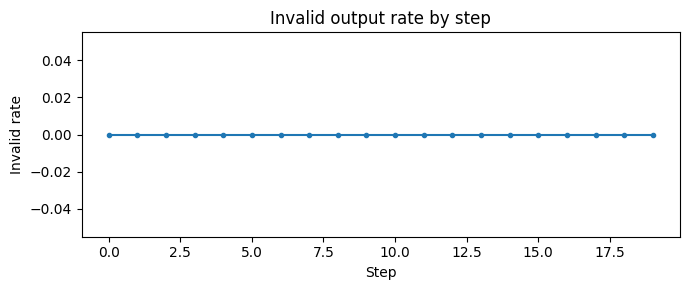

In [52]:
invalid = df[~df["action_valid"]].copy()
invalid["reason"] = invalid["action_invalid_reason"]
by_step = df.groupby("step").agg(
    invalid_rate=("action_valid", lambda x: 1 - x.mean()),
    n=("action_valid", "count"),
).reset_index()
by_ep_inv = df.groupby("episode_id").agg(
    invalid_rate=("action_valid", lambda x: 1 - x.mean()),
    n=("action_valid", "count"),
).reset_index()

summary_inv = {
    "overall_invalid_rate": 1 - df["action_valid"].mean(),
    "by_reason": df[~df["action_valid"]]["action_invalid_reason"].value_counts().to_dict(),
}
inv_rows = [{"metric": "overall_invalid_rate", "value": summary_inv["overall_invalid_rate"]}]
for reason, count in summary_inv["by_reason"].items():
    inv_rows.append({"metric": f"reason_{reason}", "value": count})
pd.DataFrame(inv_rows).to_csv(OUTDIR / "invalid_output_summary.csv", index=False)

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(by_step["step"], by_step["invalid_rate"], "o-", markersize=3)
ax.set_xlabel("Step")
ax.set_ylabel("Invalid rate")
ax.set_title("Invalid output rate by step")
plt.tight_layout()
plt.savefig(OUTDIR / "invalid_rate_by_step.png", dpi=120)
plt.show()

## 8) Privileged-state diagnostics (optional)

**Policy extraction diagnostics:** If you get 0 training examples, run the cell below to see why (empty `df_valid` vs. all-NaN in feature columns).

In [53]:
def get_info(row, key):
    info = row.get("info") or {}
    if isinstance(info, dict):
        return info.get(key)
    return None

if "info" in df.columns:
    df["distance_to_source"] = df.apply(lambda r: get_info(r, "distance_to_source"), axis=1)
    df["position"] = df.apply(lambda r: get_info(r, "position"), axis=1)
    hs = df["hidden_state"]
    df["src"] = hs.apply(lambda x: x.get("source_location") if isinstance(x, dict) else None)
    df["direction"] = hs.apply(lambda x: x.get("direction") if isinstance(x, dict) else None)

    df["distance_after"] = df["distance_to_source"]
    df["distance_before"] = df.groupby("episode_id")["distance_to_source"].shift(1)
    df["progress"] = df["distance_after"] < df["distance_before"]
    prog = df[df["action_valid"]].groupby("action").agg(progress_mean=("progress", "mean"), n=("progress", "count")).reset_index()
    prog.to_csv(OUTDIR / "progress_by_action.csv", index=False)

    moving_away = (df["direction"] * (df["src"] - df["position"]) < 0) & (df["action"] == "RUN")
    wrong_way = {
        "wrong_way_run_count": int(moving_away.sum()),
        "total_run_steps": int((df["action"] == "RUN").sum()),
        "wrong_way_run_rate": float(moving_away.sum() / max((df["action"] == "RUN").sum(), 1)),
    }
    with open(OUTDIR / "wrong_way_run_stats.json", "w") as f:
        json.dump(wrong_way, f, indent=2)
else:
    wrong_way = {"wrong_way_run_count": None, "wrong_way_run_rate": None}
    with open(OUTDIR / "wrong_way_run_stats.json", "w") as f:
        json.dump(wrong_way, f)

## 9) Report and within-episode summary

In [54]:
def compute_within_episode_summary(df_in, df_valid_in, metrics_in, policy_metrics_in, seg_df_in=None, rho_in=None, thr_pos=0.2, thr_neg=-0.2):
    d = {
        "invalid_rate": float(1 - df_in["action_valid"].mean()),
        "p_run_when_delta3_pos": float(df_valid_in[(df_valid_in["delta_3"] > thr_pos)]["action_run"].mean()) if (df_valid_in["delta_3"] > thr_pos).any() else None,
        "p_run_when_delta3_neg": float(df_valid_in[(df_valid_in["delta_3"] < thr_neg)]["action_run"].mean()) if (df_valid_in["delta_3"] < thr_neg).any() else None,
        "mean_run_length": float(seg_df_in[seg_df_in["action"] == "RUN"]["segment_len"].mean()) if seg_df_in is not None and len(seg_df_in[seg_df_in["action"] == "RUN"]) > 0 else None,
        "corr_runlen_trend": float(rho_in) if rho_in is not None and not (isinstance(rho_in, float) and np.isnan(rho_in)) else None,
        "logreg_auc": policy_metrics_in.get("logreg_auc"),
        "tree_acc": policy_metrics_in.get("tree_accuracy"),
    }
    return d

summary_dict = compute_within_episode_summary(df, df_valid, metrics, policy_metrics, seg_df_in=seg_df if 'seg_df' in dir() else None, rho_in=rho if 'rho' in dir() else None)
summary_dict["model_name"] = metrics.get("summary", {}).get("model_name")
summary_dict["num_episodes"] = metrics.get("summary", {}).get("num_episodes")
with open(OUTDIR / "within_episode_summary.json", "w") as f:
    json.dump(summary_dict, f, indent=2)

KeyError: 'action_run'

In [ ]:
report = []
report.append("# Within-Episode Analysis Report\n")
report.append(f"- Rows: {basic['n_rows']}, Episodes: {basic['n_episodes']}, Invalid action rate: {basic['invalid_action_rate']:.4f}\n")
report.append("## Key results")
report.append(f"- P(RUN | delta_3 > 0.2): {summary_dict.get('p_run_when_delta3_pos')}")
report.append(f"- P(RUN | delta_3 < -0.2): {summary_dict.get('p_run_when_delta3_neg')}")
report.append(f"- Mean run length: {summary_dict.get('mean_run_length')}")
report.append(f"- Run length vs trend (Spearman): {summary_dict.get('corr_runlen_trend')}")
report.append(f"- LogReg AUC: {summary_dict.get('logreg_auc')}, Tree accuracy: {summary_dict.get('tree_acc')}")
report.append("\n## Generated files")
for p in sorted(OUTDIR.iterdir()):
    report.append(f"- {p.name}")
report.append(f"\nModel: {summary_dict.get('model_name')}, Episodes: {summary_dict.get('num_episodes')}")

with open(OUTDIR / "report_within_episode.md", "w") as f:
    f.write("\n".join(report))
print("Report written to", OUTDIR / "report_within_episode.md")